In [1]:
import pandas as pd
import datetime
from glob import glob
from tqdm import tqdm
import numpy as np
import xarray as xr
import torch
#import pickle
#import dask
import warnings
warnings.filterwarnings('ignore')
import os
import matplotlib.pyplot as plt
from ndfd_precip_cmap import NWSPrecipitation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import matplotlib
from mpl_toolkits.basemap import Basemap
matplotlib.rcParams.update({
 "savefig.facecolor": "w",
 "figure.facecolor" : 'w',
 "figure.figsize" : (8,6),
 "text.color": "k",
 "legend.fontsize" : 20,
 "font.size" : 30,
 "axes.edgecolor": "k",
 "axes.labelcolor": "k",
 "axes.linewidth": 3,
 "xtick.color": "k",
 "ytick.color": "k",
 "xtick.labelsize" : 25,
 "ytick.labelsize" : 25,
 "ytick.major.size" : 12,
 "xtick.major.size" : 12,
 "ytick.major.width" : 2,
 "xtick.major.width" : 2,
 "font.family": 'STIXGeneral',
 "mathtext.fontset" : "cm"})


In [2]:
saved_state = torch.load('/scratch4/STI/mdl-sti/Sidney.Lower/scripts/qmd_ml/dave_rudack/downscaling/models/PQPF_downscale_MRMS_VERSION2.pth', map_location=torch.device('cpu'))

In [3]:
train_loss = saved_state['metrics']['training_loss']
val_loss = saved_state['metrics']['validation_loss']
epochs = np.arange(1, len(val_loss)+1)

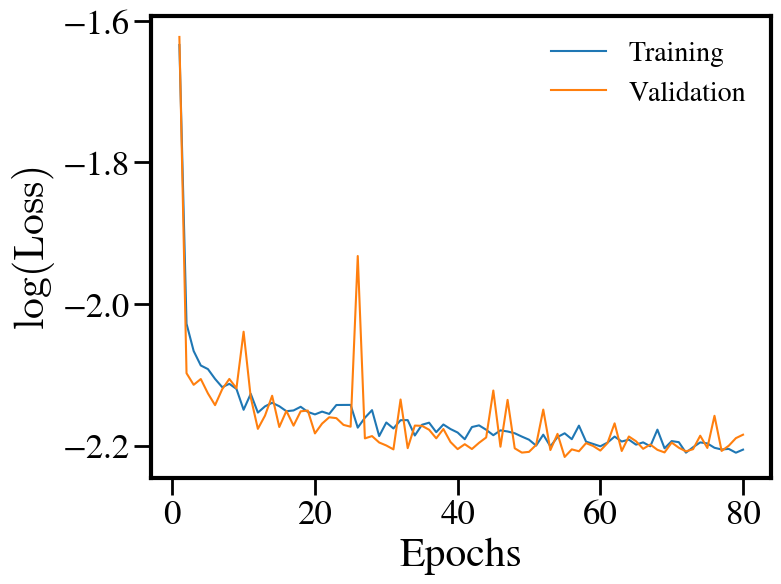

In [4]:
plt.plot(epochs, np.log10(train_loss), label='Training')
plt.plot(epochs, np.log10(val_loss), label='Validation')

plt.ylabel("$\log(\mathrm{Loss})$")
plt.xlabel("Epochs")
plt.legend(frameon=False)

# Test with hold-out MRMS data

In [5]:
import grib2io
import dask

class load_MRMS_data(torch.utils.data.Dataset):
    def __init__(self, mrms_path: str):

        self.mrms_file = mrms_path
        self.mrms_ds = None
        
        with xr.open_dataset(mrms_path, engine="zarr", consolidated=True) as ds:
                ndates = ds.validDate.size
        self.n_samples = ndates

        # stats for normalizing wrt training data
        qpe_stats = xr.open_dataset(
            "/scratch4/STI/mdl-sti/Sidney.Lower/data/mrms/downscaling_training_stats.nc"
        ).load()
        self.precip_mean = qpe_stats.mean_log_precip.values
        self.precip_std = qpe_stats.std_log_precip.values

        # Process LOW RES terrain features
        terrain_file = (
            "/scratch4/STI/mdl-sti/Sidney.Lower/data/mrms/upsampled_terrain20km.nc"
        )
        ds_topo_data = xr.open_dataset(terrain_file).load()
        terrain_tensor = (
            torch.from_numpy(np.nan_to_num(ds_topo_data.terrain20km.values, 0.0))
            .float()
            .unsqueeze(0)
        )
        lowres_features = terrain_tensor  # torch.cat([terrain_tensor], dim=0)

        # Process HIGH RES terrain features
        terrain_file = "/scratch4/STI/mdl-sti/David.Rudack/qpf_ai/pred_data/terrain_2p5km_nml_to.nc"
        ds_topo_data = xr.open_dataset(terrain_file).load()
        terrain_tensor = (
            torch.from_numpy(np.nan_to_num(ds_topo_data.nml_terrain_2p5km.values, 0.0))
            .float()
            .unsqueeze(0)
        )
        self.highres_terrain = terrain_tensor  # torch.cat([terrain_tensor_HR, slope_tensor_HR, aspect_tensor_HR], dim=0)

        # Compute elevation gradient, difference between 20km and 2.5km resolution
        self.elev_diff = self.highres_terrain - lowres_features

        # grib2 grid defs for 20km and 2.5km
        # ignore Dave's sloppy file naming :)
        grid2p5 = grib2io.open(
            "/scratch4/STI/mdl-sti/David.Rudack/qpf_ai/hiresw.t00z.arw_2p5km_2025030600.grib2"
        )
        grid20 = grib2io.open(
            "/scratch4/STI/mdl-sti/David.Rudack/herbie_data/hiresw.t00z.fv3_5km_2025053100.grib2"
        )

        self.g20km3 = grid20[0].section3
        self.g2p5km3 = grid2p5[0].section3
        self.grid_out20 = grib2io.Grib2GridDef.from_section3(grid20[0].section3)
        self.grid_out2p5 = grib2io.Grib2GridDef.from_section3(grid2p5[0].section3)

    def _get_mrms_ds(self):
        # same as above
        # if RTMA file is already open, just return that
        if self.mrms_ds is None:
            ds = xr.open_dataset(self.mrms_file)
            # on first time opening, load valid dates for quick look up later
            ds.validDate.load()
            self.mrms_ds = ds
        return self.mrms_ds
        

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):

        ds_mrms = self._get_mrms_ds()

        mrms = ds_mrms.MultiSensor_QPE_24H_Pass2
        valid_date = pd.to_datetime(ds_mrms.validDate.values)

        # feature (input) = 20km grid
        # target (output) = ratio of 2.5km to 20km (multiplicative correction to 20km grid)
        
        interp20_to_2p5 = np.nan_to_num(mrms.sel(resolution='20').values)
        interp2p5 = np.nan_to_num(mrms.sel(resolution='2.5').values)
        num = interp2p5
        denom = interp20_to_2p5 + 1e-9
        threshold = 0.1
        target = np.nan_to_num(np.where(num > threshold, np.divide(num, denom), 0.0))

        # normalize
        logp1_feature = np.log1p(interp20_to_2p5)
        normalized_feature = (logp1_feature - self.precip_mean) / self.precip_std
        normalized_target = np.log1p(target)

        # add timing tensors
        day_of_year = valid_date.day_of_year
        ending_hour = int(valid_date.hour)
        days_in_year = 366.0 if valid_date.is_leap_year else 365.0
        sin_time = np.sin(2 * np.pi * day_of_year / days_in_year)
        cos_time = np.cos(2 * np.pi * day_of_year / days_in_year)
        ending_hour_sin = np.sin(2 * np.pi * (ending_hour / 24.0))
        ending_hour_cos = np.cos(2 * np.pi * (ending_hour / 24.0))

        # to be injected with the FiLM Layers [4, 1]
        time_vector = torch.tensor(
            [sin_time, cos_time, ending_hour_sin, ending_hour_cos], dtype=torch.float32
        )
        # shape [3, 2.5km H, 2.5km W]
        feature_tensor = torch.tensor(
            normalized_feature, dtype=torch.float32
        ).unsqueeze(0)
        combined_features = torch.cat(
            [feature_tensor, self.highres_terrain, self.elev_diff], dim=0
        )
        # shape [1, 2.5km H, 2.5km W]
        target_tensor = torch.tensor(normalized_target, dtype=torch.float32).unsqueeze(
            0
        )

        return combined_features.unsqueeze(0), target_tensor, time_vector.unsqueeze(0), interp20_to_2p5, interp2p5

In [6]:
from downscale_model import init_model

In [7]:
with xr.open_dataset('/scratch4/STI/mdl-sti/Eric.Engle/FROM_scratch1_mdl/gitrepos/blend/fix/precip/blend.precip_const.co.2p5.nc') as temp:
    latitude = temp.latitude.values
    longitude = temp.longitude.values
ny, nx = np.shape(longitude) 

In [8]:
in_channels = saved_state['model_args']['in_channels']
features = saved_state['model_args']['n_features_max']
n_conv_layers = saved_state['model_args']['n_conv_layers']

In [9]:
downscale_model = init_model(grid_dims=(ny, nx),in_channels=in_channels,features=features,n_conv_layers=n_conv_layers)
downscale_model.load_state_dict(saved_state['model_state_dict'])

<All keys matched successfully>

In [10]:
td = datetime.datetime(2026, 5, 26, 0)
mrms_2026 = glob(f"/scratch4/STI/mdl-sti/Sidney.Lower/data/mrms/downscaling_data/testing/mrms_2p5_{td.strftime('%Y%m%d%H')}.zarr")

In [130]:
mrms_2026

['/scratch4/STI/mdl-sti/Sidney.Lower/data/mrms/downscaling_data/testing/mrms_2p5_2026052600.zarr']

In [11]:
test_dataset = load_MRMS_data(mrms_2026[0])

In [12]:
downscale_model.eval()
torch.no_grad()
for inputs, target, time_vector, mrms_grid20, grid2p5 in tqdm(test_dataset):
    outputs = downscale_model(inputs, time_vector)

100%|██████████| 1/1 [01:13<00:00, 73.62s/it]


KeyboardInterrupt: 

In [14]:
hires_pred = np.expm1(outputs.squeeze(0).squeeze(0).detach().numpy()) *mrms_grid20

Text(0.5, 1.0, '2026-05-26 00z | Downscaled')

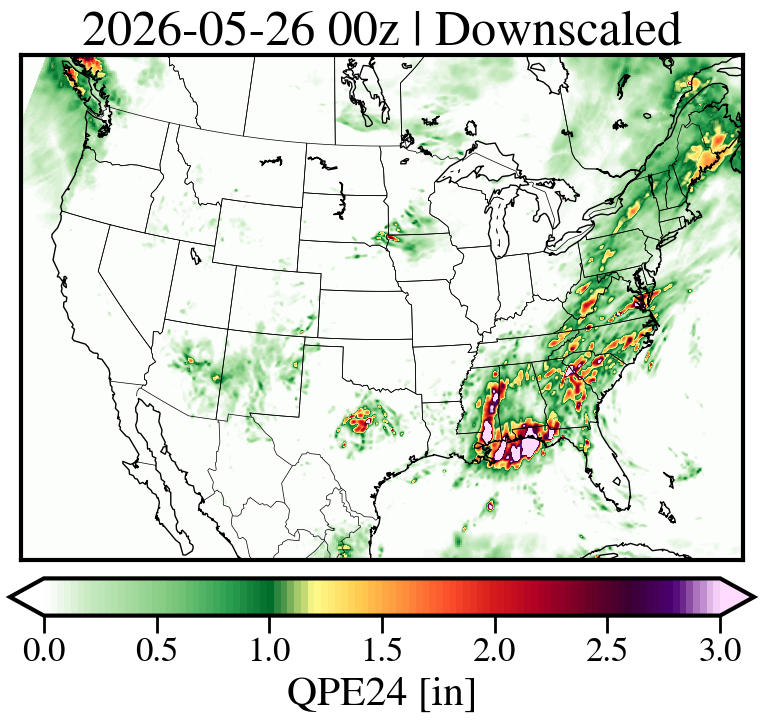

In [15]:
fig, axes = plt.subplots(1,1, figsize=(12,8))
m = Basemap(projection='lcc',lon_0=-97,lat_0=39,width=5e6,height=3.5e6, resolution='l')
xx, yy = m(longitude,latitude)
ll = np.linspace(0,3,101)
cs = m.contourf(xx,yy,hires_pred/25.4,ax=axes,extend='both',cmap=NWSPrecipitation.cmap, levels=ll)

cb=plt.colorbar(cs, shrink=0.8,pad=0.03, orientation='horizontal', ticks=np.arange(0,3.5, 0.5))
cb.set_label(f'QPE24 [in]', labelpad=5)
m.drawcoastlines(ax=axes, color='black')
m.drawlsmask(ax=axes)
m.drawcountries(ax=axes, color='black')
m.drawstates(ax=axes, color='black')
plt.title(f"{td.strftime('%Y-%m-%d %H')}z | Downscaled")

Text(0.5, 1.0, '2026-05-26 00z | MRMS 20km')

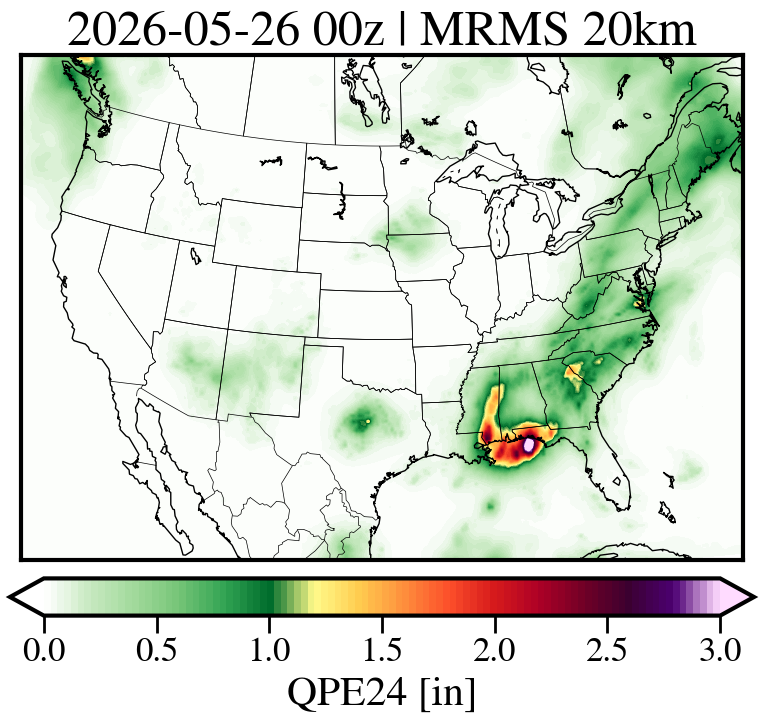

In [42]:
fig, axes = plt.subplots(1,1, figsize=(12,8))
m = Basemap(projection='lcc',lon_0=-97,lat_0=39,width=5e6,height=3.5e6, resolution='l')
xx, yy = m(longitude,latitude)
ll = np.linspace(0,3,101)
cs = m.contourf(xx,yy,grid20/25.4,ax=axes,extend='both',cmap=NWSPrecipitation.cmap, levels=ll)

cb=plt.colorbar(cs, shrink=0.8,pad=0.03, orientation='horizontal', ticks=np.arange(0,3.5, 0.5))
cb.set_label(f'QPE24 [in]', labelpad=5)
m.drawcoastlines(ax=axes, color='black')
m.drawlsmask(ax=axes)
m.drawcountries(ax=axes, color='black')
m.drawstates(ax=axes, color='black')
plt.title(f"{td.strftime('%Y-%m-%d %H')}z | MRMS 20km")

Text(0.5, 1.0, '2026-05-26 00z | MRMS 2.5km')

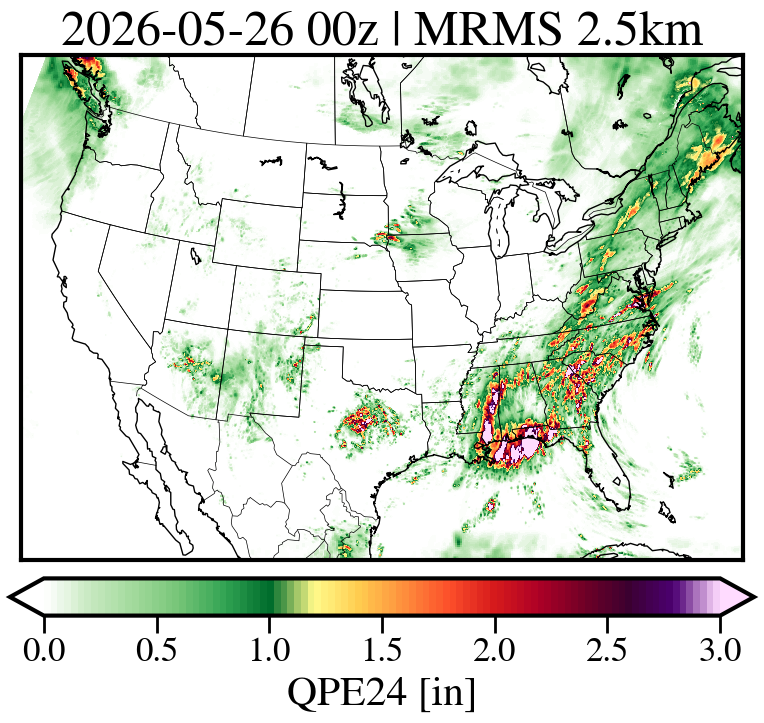

In [43]:
fig, axes = plt.subplots(1,1, figsize=(12,8))
m = Basemap(projection='lcc',lon_0=-97,lat_0=39,width=5e6,height=3.5e6, resolution='l')
xx, yy = m(longitude,latitude)
ll = np.linspace(0,3,101)
cs = m.contourf(xx,yy,grid2p5/25.4,ax=axes,extend='both',cmap=NWSPrecipitation.cmap, levels=ll)

cb=plt.colorbar(cs, shrink=0.8,pad=0.03, orientation='horizontal', ticks=np.arange(0,3.5, 0.5))
cb.set_label(f'QPE24 [in]', labelpad=5)
m.drawcoastlines(ax=axes, color='black')
m.drawlsmask(ax=axes)
m.drawcountries(ax=axes, color='black')
m.drawstates(ax=axes, color='black')
plt.title(f"{td.strftime('%Y-%m-%d %H')}z | MRMS 2.5km")

# now test on predictions?

In [16]:
lead_time = 24

data_dir = "/scratch4/STI/mdl-sti/Sidney.Lower/data/ai_pqpf/"
pred_data = sorted(glob(data_dir+f"AI_percentile_predictions_qpf24_*_{lead_time}h.grib2"))
for pp in pred_data:
    print(pp)

/scratch4/STI/mdl-sti/Sidney.Lower/data/ai_pqpf/AI_percentile_predictions_qpf24_2026060100_24h.grib2
/scratch4/STI/mdl-sti/Sidney.Lower/data/ai_pqpf/AI_percentile_predictions_qpf24_2026060112_24h.grib2
/scratch4/STI/mdl-sti/Sidney.Lower/data/ai_pqpf/AI_percentile_predictions_qpf24_2026060200_24h.grib2
/scratch4/STI/mdl-sti/Sidney.Lower/data/ai_pqpf/AI_percentile_predictions_qpf24_2026060212_24h.grib2
/scratch4/STI/mdl-sti/Sidney.Lower/data/ai_pqpf/AI_percentile_predictions_qpf24_2026060300_24h.grib2


In [53]:
ai_qpf = xr.open_dataset(pred_data[0], engine='grib2io')

In [37]:
ai_qpf

<xarray.Dataset> Size: 255MB
Dimensions:                    (percentileValue: 13, y: 1597, x: 2345)
Coordinates:
  * percentileValue            (percentileValue) int64 104B 5 10 20 ... 80 90 95
    refDate                    datetime64[ns] 8B ...
    leadTime                   timedelta64[ns] 8B ...
    duration                   timedelta64[ns] 8B ...
    valueOfFirstFixedSurface   float64 8B ...
    valueOfSecondFixedSurface  float64 8B ...
    latitude                   (y, x) float64 30MB ...
    longitude                  (y, x) float64 30MB ...
    validDate                  datetime64[ns] 8B ...
Dimensions without coordinates: y, x
Data variables:
    APCP                       (percentileValue, y, x) float32 195MB ...
Attributes:
    crs_wkt:                  PROJCRS["unknown",BASEGEOGCRS["unknown",DATUM["...
    gridlengthXDirection:     2539.703
    gridlengthYDirection:     2539.703
    latitudeFirstGridpoint:   19.229
    longitudeFirstGridpoint:  233.7234
    engine:                   grib2io

In [17]:
ny, nx = ai_qpf.latitude.shape

In [54]:
valid_date = pd.to_datetime(ai_qpf.validDate.values)
print(valid_date)

2026-06-02 00:00:00


In [55]:
lowres_pred = ai_qpf.APCP.sel(percentileValue=50).values

Text(0.5, 1.0, '2026-06-02 00z | AI PQPF 20km')

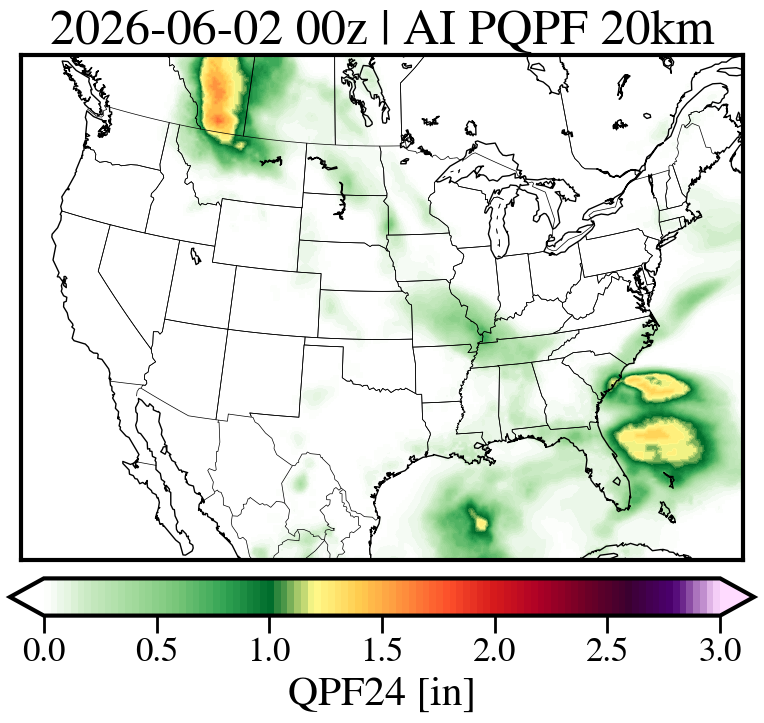

In [56]:
fig, axes = plt.subplots(1,1, figsize=(12,8))
m = Basemap(projection='lcc',lon_0=-97,lat_0=39,width=5e6,height=3.5e6, resolution='l')
xx, yy = m(longitude,latitude)
ll = np.linspace(0,3,101)
cs = m.contourf(xx,yy,lowres_pred/25.4,ax=axes,extend='both',cmap=NWSPrecipitation.cmap, levels=ll)

cb=plt.colorbar(cs, shrink=0.8,pad=0.03, orientation='horizontal', ticks=np.arange(0,3.5, 0.5))
cb.set_label(f'QPF24 [in]', labelpad=5)
m.drawcoastlines(ax=axes, color='black')
m.drawlsmask(ax=axes)
m.drawcountries(ax=axes, color='black')
m.drawstates(ax=axes, color='black')
plt.title(f"{valid_date.strftime('%Y-%m-%d %H')}z | AI PQPF 20km")

In [222]:
## this handles the grib2io log messages that we don't need here
import os
from contextlib import contextmanager, redirect_stdout
import dask
import grib2io
#import torchvision.transforms.functional as TF

@contextmanager
def suppress_stdout():
    """Context manager to suppress both Python and C-level stdout."""
    # Open devnull to send output into the void
    with open(os.devnull, 'w') as devnull:
        # Save the original file descriptor
        old_stdout_fd = os.dup(1)
        try:
            # Redirect Python's stdout
            with redirect_stdout(devnull):
                # Redirect low-level file descriptor 1 (stdout) to devnull
                os.dup2(devnull.fileno(), 1)
                yield
        finally:
            # Restore the original file descriptor
            os.dup2(old_stdout_fd, 1)
            os.close(old_stdout_fd)

import scipy.ndimage as ndimage

def clear_categorical_banding(ai_data, noise_std=5., blur_sigma=5.):
    """
    Dithers and smooths the piecewise-linear AI data to restore a 
    continuous, physical gradient curve before downscaling.
    """
    # 1. Add a tiny bit of Gaussian noise (Dithering)
    # This instantly shatters the flat, rigid linear plateaus and jagged contours
    rain_mask = ai_data > 0.254
    noise = np.random.normal(0, noise_std, ai_data.shape) * rain_mask
    dithered_data = ai_data + noise
    
    # 2. Apply a light Gaussian blur to the dithered data
    # The blur blends the noise and the steps together, turning the 
    # rigid "staircase" into a smooth, natural, continuous slope
    smoothed_data = ndimage.gaussian_filter(dithered_data, sigma=blur_sigma)
    
    # 3. Clean up boundaries
    smoothed_data = np.clip(smoothed_data, a_min=0.0, a_max=None)
    smoothed_data[~rain_mask] = 0.0
    
    return smoothed_data

def feather_cliff_edges(ai_data, threshold=0.254, decay_rate=0.02):
    """
    Finds the blunt cliff edges in the AI data and replaces them with a 
    gentle, non-linear physical decay tail matching the MRMS edge topology.
    """
    # 1. Create a binary mask of where the rain is actively falling
    rain_mask = ai_data > threshold
    
    # 2. Calculate a Distance Transform
    # This measures exactly how many pixels deep any given point is inside the storm
    distance_map = ndimage.distance_transform_edt(rain_mask)
    
    # 3. Create an exponential feathering profile for the outer margins
    # Pixels deep inside the storm core (distance > 4) remain perfectly untouched (multiplier = 1.0)
    # Pixels right at the edge (distance 1 to 3) get progressively scaled down to form a smooth curve
    feather_multiplier = 1.0 - np.exp(-distance_map * decay_rate)
    
    # 4. Apply the feathering to the data
    feathered_data = ai_data * feather_multiplier
    
    # Enforce the final hard cutoff boundary cleanly
    feathered_data[~rain_mask] = 0.0
    
    return feathered_data

class load_qpf_data(torch.utils.data.Dataset):
    def __init__(self, data_path: list, percentile=50):

        self.qpf_percentile = percentile
        self.data_files = data_path
        self.ds = None

        if 'grib2' in self.data_files[0]:
            self.ds_format = 'grib2'
            #with xr.open_dataset(data_path, engine="grib2io") as ds:
            #    ndates = ds.validDate.size
        elif 'zarr' in self.data_files[0]:
            self.ds_format = 'zarr'
            #with xr.open_dataset(data_path,) as ds:
            #    ndates = ds.validDate.size
        
        self.n_samples = len(data_path)

        # stats for normalizing wrt training data
        qpe_stats = xr.open_dataset(
            "/scratch4/STI/mdl-sti/Sidney.Lower/data/mrms/downscaling_training_stats.nc"
        ).load()
        self.precip_mean = qpe_stats.mean_log_precip.values
        self.precip_std = qpe_stats.std_log_precip.values

        psd_scale = xr.open_dataset('/scratch4/STI/mdl-sti/Sidney.Lower/data/mrms/downscaling_data/psd_scaling_20km.zarr')
        self.psd_scale = psd_scale.psd_scale_2d.values

        # Process LOW RES terrain features
        terrain_file = (
            "/scratch4/STI/mdl-sti/Sidney.Lower/data/mrms/upsampled_terrain20km.nc"
        )
        ds_topo_data = xr.open_dataset(terrain_file).load()
        terrain_tensor = (
            torch.from_numpy(np.nan_to_num(ds_topo_data.terrain20km.values, 0.0))
            .float()
            .unsqueeze(0)
        )
        lowres_features = terrain_tensor  # torch.cat([terrain_tensor], dim=0)

        # Process HIGH RES terrain features
        terrain_file = "/scratch4/STI/mdl-sti/David.Rudack/qpf_ai/pred_data/terrain_2p5km_nml_to.nc"
        ds_topo_data = xr.open_dataset(terrain_file).load()
        terrain_tensor = (
            torch.from_numpy(np.nan_to_num(ds_topo_data.nml_terrain_2p5km.values, 0.0))
            .float()
            .unsqueeze(0)
        )
        self.highres_terrain = terrain_tensor  # torch.cat([terrain_tensor_HR, slope_tensor_HR, aspect_tensor_HR], dim=0)

        # Compute elevation gradient, difference between 20km and 2.5km resolution
        self.elev_diff = self.highres_terrain - lowres_features

        # grib2 grid defs for 20km and 2.5km
        # ignore Dave's sloppy file naming :)
        grid2p5 = grib2io.open(
            "/scratch4/STI/mdl-sti/David.Rudack/qpf_ai/hiresw.t00z.arw_2p5km_2025030600.grib2"
        )
        grid20 = grib2io.open(
            "/scratch4/STI/mdl-sti/David.Rudack/herbie_data/hiresw.t00z.fv3_5km_2025053100.grib2"
        )

        self.g20km3 = grid20[0].section3
        self.g2p5km3 = grid2p5[0].section3
        self.grid_out20 = grib2io.Grib2GridDef.from_section3(grid20[0].section3)
        self.grid_out2p5 = grib2io.Grib2GridDef.from_section3(grid2p5[0].section3)

    def _get_ds(self, ):
        # same as above
        # if RTMA file is already open, just return that
        if self.ds is None:
            if self.ds_format == 'grib2':
                ds = xr.open_dataset(self.data_file, engine='grib2io')
            elif self.ds_format == 'zarr':
                ds = xr.open_dataset(self.data_files)
            # on first time opening, load valid dates for quick look up later
            ds.validDate.load()
            self.ds = ds
        return self.ds

    def __len__(self):
        return self.n_samples


    def __getitem__(self, idx):

        if self.ds_format == 'grib2':
            ds = xr.open_dataset(self.data_files[idx], engine='grib2io')
        elif self.ds_format == 'zarr':
            ds = xr.open_dataset(self.data_files[idx])
            
        valid_date = pd.to_datetime(ds.validDate.values)

        if self.ds_format == 'grib2':
            interp20_to_2p5 = np.nan_to_num(ds.APCP.sel(percentileValue=self.qpf_percentile).values, 0.0)
        elif self.ds_format == 'zarr':
            interp20_to_2p5 = np.nan_to_num(ds.pqpf24_percentile_prediction.sel(percentiles=self.qpf_percentile).values, 0.0)

        smoothed = sgolay2d(feather_cliff_edges(interp20_to_2p5), 9, 3)

        logp1_feature = np.log1p(feather_cliff_edges(interp20_to_2p5))
        normalized_feature = (logp1_feature - self.precip_mean) / self.precip_std

        # add timing tensors
        day_of_year = valid_date.day_of_year
        ending_hour = int(valid_date.hour)
        days_in_year = 366.0 if valid_date.is_leap_year else 365.0
        sin_time = np.sin(2 * np.pi * day_of_year / days_in_year)
        cos_time = np.cos(2 * np.pi * day_of_year / days_in_year)
        ending_hour_sin = np.sin(2 * np.pi * (ending_hour / 24.0))
        ending_hour_cos = np.cos(2 * np.pi * (ending_hour / 24.0))

        # to be injected with the FiLM Layers [4, 1]
        time_vector = torch.tensor(
            [sin_time, cos_time, ending_hour_sin, ending_hour_cos], dtype=torch.float32
        )
        # shape [3, 2.5km H, 2.5km W]
        feature_tensor = torch.tensor(
            normalized_feature, dtype=torch.float32
        ).unsqueeze(0)
        combined_features = torch.cat(
            [feature_tensor, self.highres_terrain, self.elev_diff], dim=0
        )

        return combined_features.unsqueeze(0), time_vector.unsqueeze(0), interp20_to_2p5, valid_date.strftime("%Y%m%d%H")

from scipy import ndimage, signal
def sgolay2d (z, window_size, order, derivative=None):
    """
    Apply a Savitsky-Golay filter to a 2D array.
    """
    # number of terms in the polynomial expression
    n_terms = ( order + 1 ) * ( order + 2)  / 2.0

    if  window_size % 2 == 0:
        raise ValueError('window_size must be odd')

    if window_size**2 < n_terms:
        raise ValueError('order is too high for the window size')

    half_size = window_size // 2

    # exponents of the polynomial.
    # p(x,y) = a0 + a1*x + a2*y + a3*x^2 + a4*y^2 + a5*x*y + ...
    # this line gives a list of two item tuple. Each tuple contains
    # the exponents of the k-th term. First element of tuple is for x
    # second element for y.
    # Ex. exps = [(0,0), (1,0), (0,1), (2,0), (1,1), (0,2), ...]
    exps = [ (k-n, n) for k in range(order+1) for n in range(k+1) ]

    # coordinates of points
    ind = np.arange(-half_size, half_size+1, dtype=np.float32)
    dx = np.repeat( ind, window_size )
    dy = np.tile( ind, [window_size, 1]).reshape(window_size**2, )

    # build matrix of system of equation
    A = np.empty( (window_size**2, len(exps)) )
    for i, exp in enumerate( exps ):
        A[:,i] = (dx**exp[0]) * (dy**exp[1])

    # pad input array with appropriate values at the four borders
    new_shape = z.shape[0] + 2*half_size, z.shape[1] + 2*half_size
    Z = np.zeros( (new_shape) )
    # top band
    band = z[0, :]
    Z[:half_size, half_size:-half_size] =  band -  np.abs( np.flipud( z[1:half_size+1, :] ) - band )
    # bottom band
    band = z[-1, :]
    Z[-half_size:, half_size:-half_size] = band  + np.abs( np.flipud( z[-half_size-1:-1, :] )  -band )
    # left band
    band = np.tile( z[:,0].reshape(-1,1), [1,half_size])
    Z[half_size:-half_size, :half_size] = band - np.abs( np.fliplr( z[:, 1:half_size+1] ) - band )
    # right band
    band = np.tile( z[:,-1].reshape(-1,1), [1,half_size] )
    Z[half_size:-half_size, -half_size:] =  band + np.abs( np.fliplr( z[:, -half_size-1:-1] ) - band )
    # central band
    Z[half_size:-half_size, half_size:-half_size] = z

    # top left corner
    band = z[0,0]
    Z[:half_size,:half_size] = band - np.abs( np.flipud(np.fliplr(z[1:half_size+1,1:half_size+1]) ) - band )
    # bottom right corner
    band = z[-1,-1]
    Z[-half_size:,-half_size:] = band + np.abs( np.flipud(np.fliplr(z[-half_size-1:-1,-half_size-1:-1]) ) - band )

    # top right corner
    band = Z[half_size,-half_size:]
    Z[:half_size,-half_size:] = band - np.abs( np.flipud(Z[half_size+1:2*half_size+1,-half_size:]) - band )
    # bottom left corner
    band = Z[-half_size:,half_size].reshape(-1,1)
    Z[-half_size:,:half_size] = band - np.abs( np.fliplr(Z[-half_size:, half_size+1:2*half_size+1]) - band )

    # solve system and convolve
    if derivative == None:
        m = np.linalg.pinv(A)[0].reshape((window_size, -1))
        return signal.fftconvolve(Z, m, mode='valid')
    elif derivative == 'col':
        c = np.linalg.pinv(A)[1].reshape((window_size, -1))
        return signal.fftconvolve(Z, -c, mode='valid')
    elif derivative == 'row':
        r = np.linalg.pinv(A)[2].reshape((window_size, -1))
        return signal.fftconvolve(Z, -r, mode='valid')
    elif derivative == 'both':
        c = np.linalg.pinv(A)[1].reshape((window_size, -1))
        r = np.linalg.pinv(A)[2].reshape((window_size, -1))
        return signal.fftconvolve(Z, -r, mode='valid'), signal.fftconvolve(Z, -c, mode='valid')


def batch_collate_fn(batch):
    # batch is a list of (feature, target) tuples, or None

    # Filter out the None entries
    batch = [item for item in batch if item is not None]

    # Check if the batch is now empty (all samples were bad)
    if not batch:
        print("SOmething went wrong with data loading...")
        return None, None, None, None

    return torch.utils.data.dataloader.default_collate(batch)

In [223]:
pred_data

['/scratch4/STI/mdl-sti/Sidney.Lower/data/ai_pqpf/AI_percentile_predictions_qpf24_2026060100_24h.grib2',
 '/scratch4/STI/mdl-sti/Sidney.Lower/data/ai_pqpf/AI_percentile_predictions_qpf24_2026060112_24h.grib2',
 '/scratch4/STI/mdl-sti/Sidney.Lower/data/ai_pqpf/AI_percentile_predictions_qpf24_2026060200_24h.grib2',
 '/scratch4/STI/mdl-sti/Sidney.Lower/data/ai_pqpf/AI_percentile_predictions_qpf24_2026060212_24h.grib2',
 '/scratch4/STI/mdl-sti/Sidney.Lower/data/ai_pqpf/AI_percentile_predictions_qpf24_2026060300_24h.grib2']

In [224]:
idx = 0
test_dataset = load_qpf_data([pred_data[0]], percentile=50)
#train_sampler = DistributedSampler(test_dataset, shuffle=False, rank=gpu_rank)

In [225]:
with torch.no_grad():
    for inputs, time_vector, grid20, valid_date in tqdm(test_dataset):
        outputs = downscale_model(inputs, time_vector)

100%|██████████| 1/1 [01:09<00:00, 69.16s/it]


In [232]:
hires_pred = sgolay2d(np.nan_to_num(np.expm1(outputs.squeeze(0).squeeze(0).numpy()) * grid20), 11, 3)

Text(0.5, 1.0, '2026060200z | AI PQPF Downscale')

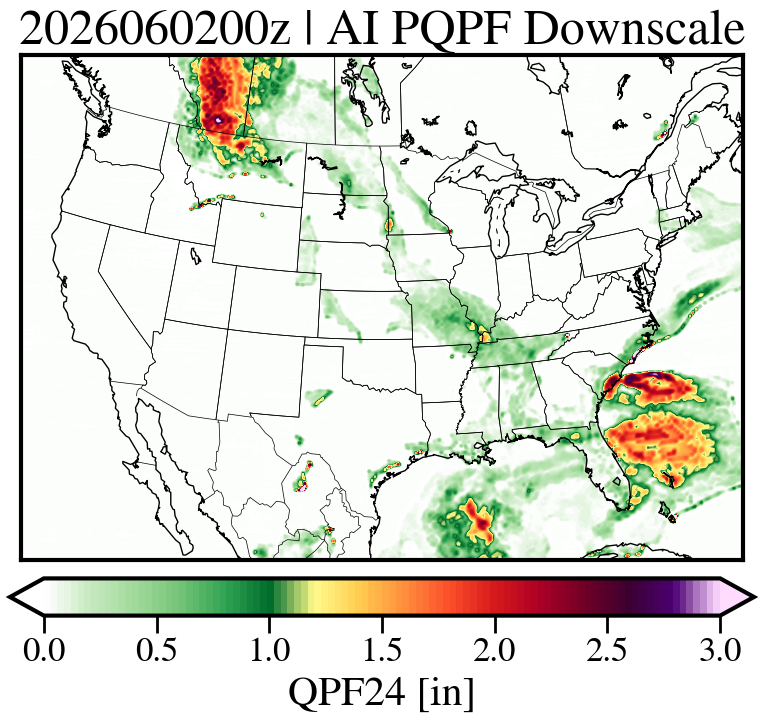

In [233]:
fig, axes = plt.subplots(1,1, figsize=(12,8))
m = Basemap(projection='lcc',lon_0=-97,lat_0=39,width=5e6,height=3.5e6, resolution='l')
xx, yy = m(longitude,latitude)
ll = np.linspace(0,3,101)
cs = m.contourf(xx,yy,hires_pred/25.4,ax=axes,extend='both',cmap=NWSPrecipitation.cmap, levels=ll)
#m.contour(xx, yy, terrain, ax=axes, cmap='grey', levels=np.linspace(0, 4000, 100), alpha=0.1)

cb=plt.colorbar(cs, shrink=0.8,pad=0.03, orientation='horizontal', ticks=np.arange(0,3.5, 0.5))
cb.set_label(f'QPF24 [in]', labelpad=5)
m.drawcoastlines(ax=axes, color='black')
m.drawlsmask(ax=axes)
m.drawcountries(ax=axes, color='black')
m.drawstates(ax=axes, color='black')
plt.title(f"{valid_date}z | AI PQPF Downscale")

In [119]:
mrms = xr.open_dataset(f'/scratch4/STI/mdl-sti/Sidney.Lower/data/mrms/downscaling_data/testing/mrms_2p5_{valid_date}.zarr')

In [120]:
mrms_qpf = np.nan_to_num(mrms.MultiSensor_QPE_24H_Pass2.sel(resolution='20').values)

Text(0.5, 1.0, '2026-06-03 00z | MRMS 2.5km')

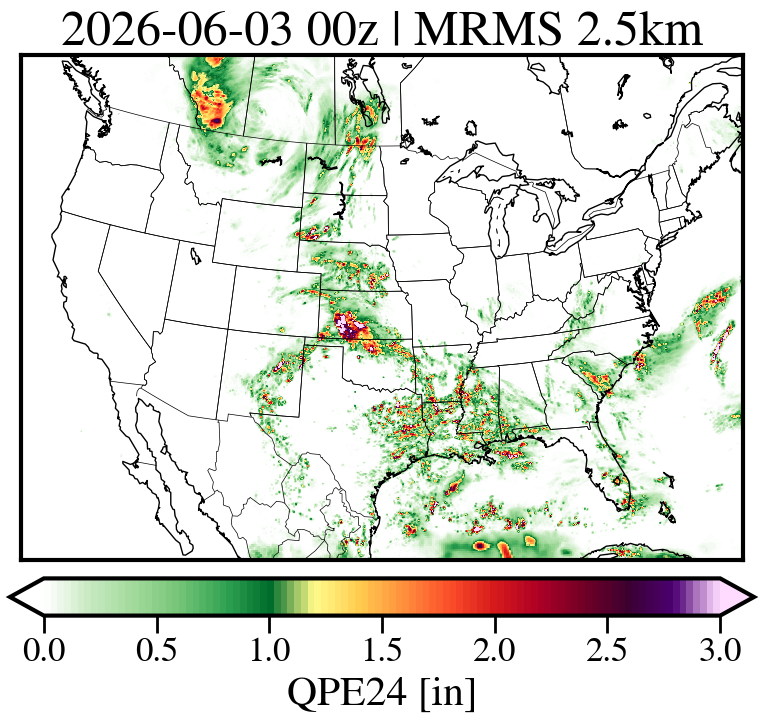

In [65]:
mrms_qpf = np.nan_to_num(mrms.MultiSensor_QPE_24H_Pass2.sel(resolution='2.5').values)

fig, axes = plt.subplots(1,1, figsize=(12,8))
m = Basemap(projection='lcc',lon_0=-97,lat_0=39,width=5e6,height=3.5e6, resolution='l')
xx, yy = m(longitude,latitude)
ll = np.linspace(0,3,101)
cs = m.contourf(xx,yy,mrms_qpf/25.4,ax=axes,extend='both',cmap=NWSPrecipitation.cmap, levels=ll)

cb=plt.colorbar(cs, shrink=0.8,pad=0.03, orientation='horizontal', ticks=np.arange(0,3.5, 0.5))
cb.set_label(f'QPE24 [in]', labelpad=5)
m.drawcoastlines(ax=axes, color='black')
m.drawlsmask(ax=axes)
m.drawcountries(ax=axes, color='black')
m.drawstates(ax=axes, color='black')
plt.title(f"{valid_date.strftime('%Y-%m-%d %H')}z | MRMS 2.5km")

# wtf is this things problem

In [121]:
pqpf_grad = np.gradient(grid20)
mrms_grad = np.gradient(mrms_qpf)

Text(0.5, 1.0, 'Model 1')

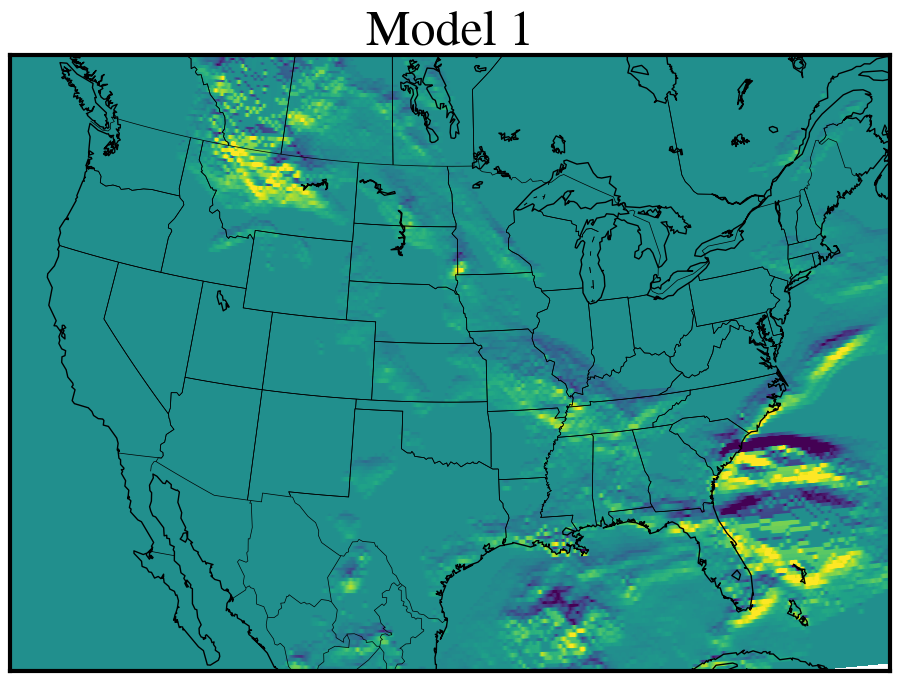

In [123]:
fig, axes = plt.subplots(1,1, figsize=(12,8))
m = Basemap(projection='lcc',lon_0=-97,lat_0=39,width=5e6,height=3.5e6, resolution='l')
xx, yy = m(longitude,latitude)
ll = np.linspace(-0.5,0.5,101)
cs = m.contourf(xx,yy,pqpf_grad[0],ax=axes,extend='both',cmap='viridis', levels=ll)
m.drawcoastlines(ax=axes, color='black')
m.drawlsmask(ax=axes)
m.drawcountries(ax=axes, color='black')
m.drawstates(ax=axes, color='black')
plt.title("Model 1")

In [165]:
import scipy

In [ ]:
np.min

In [214]:
#feathered = np.gradient(ndimage.gaussian_filter(grid20, sigma=5.))
feathered = np.gradient(feather_cliff_edges(grid20))

Text(0.5, 1.0, 'AI PQPF')

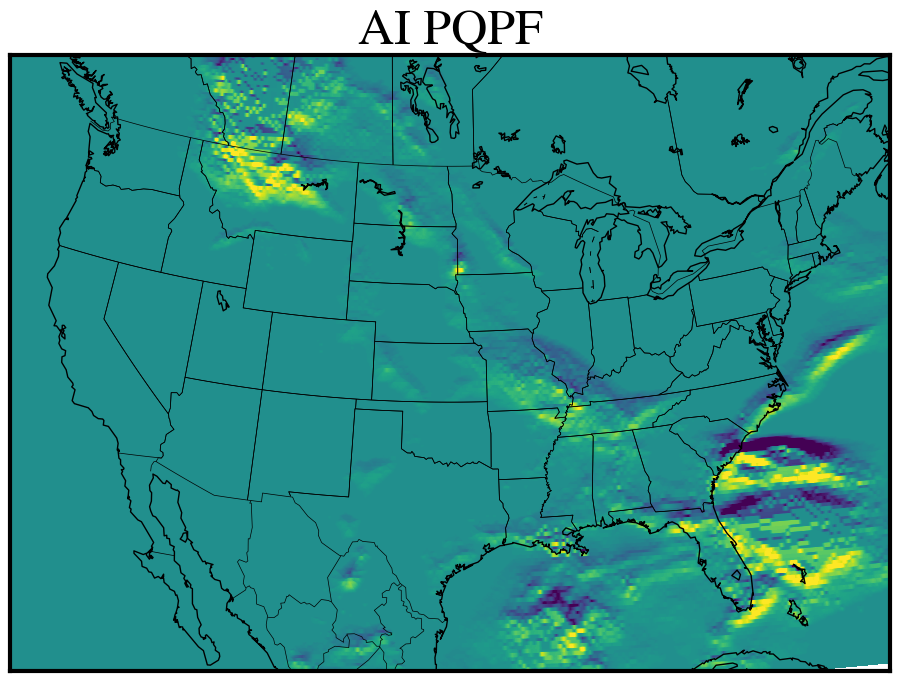

In [215]:
fig, axes = plt.subplots(1,1, figsize=(12,8))
m = Basemap(projection='lcc',lon_0=-97,lat_0=39,width=5e6,height=3.5e6, resolution='l')
xx, yy = m(longitude,latitude)
ll = np.linspace(-0.5,0.5,101)
cs = m.contourf(xx,yy,feathered[0],ax=axes,extend='both',cmap='viridis', levels=ll)
m.drawcoastlines(ax=axes, color='black')
m.drawlsmask(ax=axes)
m.drawcountries(ax=axes, color='black')
m.drawstates(ax=axes, color='black')
plt.title("AI PQPF")

Text(0.5, 1.0, 'Model 2')

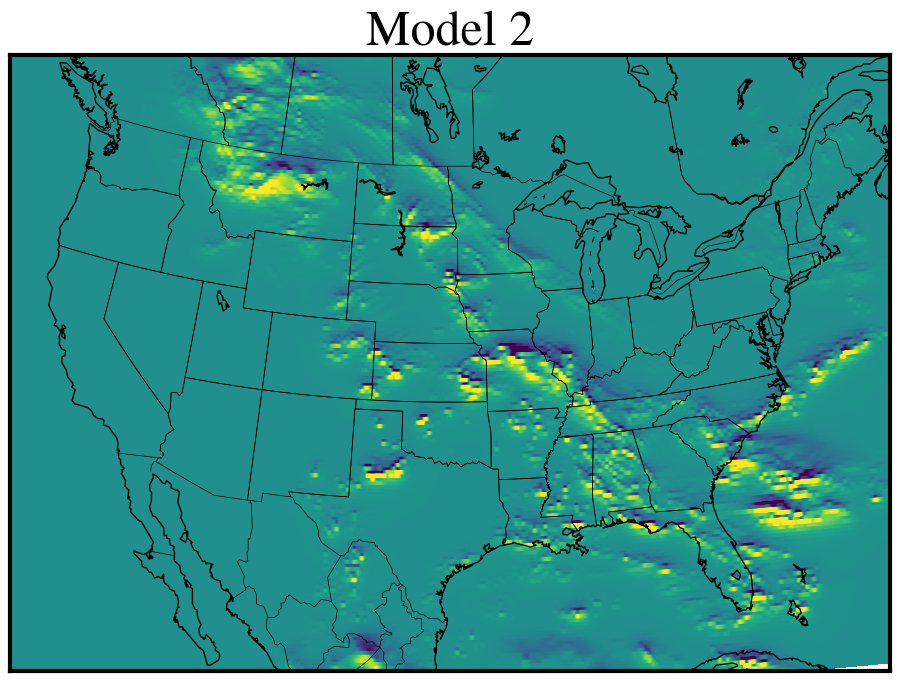

In [124]:
fig, axes = plt.subplots(1,1, figsize=(12,8))
m = Basemap(projection='lcc',lon_0=-97,lat_0=39,width=5e6,height=3.5e6, resolution='l')
xx, yy = m(longitude,latitude)
ll = np.linspace(-0.5,0.5,101)
cs = m.contourf(xx,yy,mrms_grad[0],ax=axes,extend='both',cmap='viridis', levels=ll)
m.drawcoastlines(ax=axes, color='black')
m.drawlsmask(ax=axes)
m.drawcountries(ax=axes, color='black')
m.drawstates(ax=axes, color='black')
plt.title("Model 2")

In [174]:
v5 = xr.open_dataset('/scratch4/STI/mdl-sti/Sidney.Lower/data/blend/20260601/blend.t00z.qmd.f120.co.grib2', engine='grib2io',
                    filters=dict(shortName='APCP', productDefinitionTemplateNumber=10))

In [144]:
v5

<xarray.Dataset> Size: 2GB
Dimensions:                    (percentileValue: 21, duration: 5, y: 1597,
                                x: 2345)
Coordinates:
  * percentileValue            (percentileValue) int64 168B 0 5 10 ... 90 95 100
  * duration                   (duration) timedelta64[ns] 40B 0 days 06:00:00...
    refDate                    datetime64[ns] 8B ...
    leadTime                   timedelta64[ns] 8B ...
    valueOfFirstFixedSurface   float64 8B ...
    valueOfSecondFixedSurface  float64 8B ...
    latitude                   (y, x) float64 30MB ...
    longitude                  (y, x) float64 30MB ...
    validDate                  datetime64[ns] 8B ...
Dimensions without coordinates: y, x
Data variables:
    APCP                       (percentileValue, duration, y, x) float32 2GB ...
Attributes:
    crs_wkt:                  PROJCRS["unknown",BASEGEOGCRS["unknown",DATUM["...
    gridlengthXDirection:     2539.703
    gridlengthYDirection:     2539.703
    latitudeFirstGridpoint:   19.229
    longitudeFirstGridpoint:  233.7234
    engine:                   grib2io

In [175]:
v5_qpf = v5.APCP.sel(duration=pd.Timedelta(hours=24), percentileValue=50)
valid_date = pd.to_datetime(v5.validDate.values)

Text(0.5, 1.0, '2026-06-06 00z | NBM v5 QMD QPF')

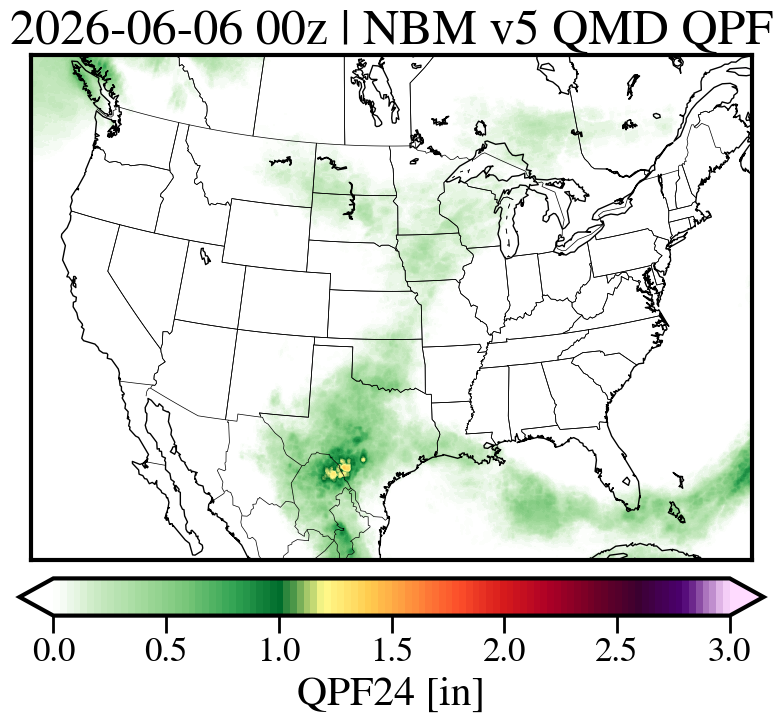

In [176]:
mrms_qpf = np.nan_to_num(v5_qpf.values)

fig, axes = plt.subplots(1,1, figsize=(12,8))
m = Basemap(projection='lcc',lon_0=-97,lat_0=39,width=5e6,height=3.5e6, resolution='l')
xx, yy = m(longitude,latitude)
ll = np.linspace(0,3,101)
cs = m.contourf(xx,yy,mrms_qpf/25.4,ax=axes,extend='both',cmap=NWSPrecipitation.cmap, levels=ll)

cb=plt.colorbar(cs, shrink=0.8,pad=0.03, orientation='horizontal', ticks=np.arange(0,3.5, 0.5))
cb.set_label(f'QPF24 [in]', labelpad=5)
m.drawcoastlines(ax=axes, color='black')
m.drawlsmask(ax=axes)
m.drawcountries(ax=axes, color='black')
m.drawstates(ax=axes, color='black')
plt.title(f"{valid_date.strftime('%Y-%m-%d %H')}z | NBM v5 QMD QPF")

In [52]:
test = xr.open_dataset('/scratch4/STI/mdl-sti/David.Rudack/qpf_ai/prediction_output/AI_percentile_predictions_pqpf24_2026052812_120h_2layer_10cat_35epocs_early_stop_2p5km.zarr')

In [53]:
test

<xarray.Dataset> Size: 449MB
Dimensions:                       (percentiles: 13, y: 1597, x: 2345)
Coordinates:
  * percentiles                   (percentiles) int64 104B 5 10 20 ... 80 90 95
    latitude                      (y, x) float64 30MB ...
    leadTime                      timedelta64[ns] 8B ...
    longitude                     (y, x) float64 30MB ...
    refDate                       datetime64[ns] 8B ...
    validDate                     datetime64[ns] 8B ...
Dimensions without coordinates: y, x
Data variables:
    pqpf24_percentile_prediction  (percentiles, y, x) float64 389MB ...

In [3]:
import numpy as np

In [6]:
percentiles = [5,10,20,25,30,40,50,60,70,75,80,90,95]

In [7]:
percentiles.index(20)

2